# Markowitz Mean-Variance Model


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tabulate import tabulate

In [38]:
try:
    df = pd.read_csv("sp500_10s.csv")
    print(df.head())
except FileNotFoundError:
    print("Error: The file was not found. Please check the file path.")
except pd.errors.EmptyDataError:
    print("Error: The file is empty.")
except pd.errors.ParserError:
    print("Error: There was a problem parsing the file. Please check the file format.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

         date     open     high      low    close     volume  Name
0  2013-02-08  67.7142  68.4014  66.8928  67.8542  158168416  AAPL
1  2013-02-11  68.0714  69.2771  67.6071  68.5614  129029425  AAPL
2  2013-02-12  68.5014  68.9114  66.8205  66.8428  151829363  AAPL
3  2013-02-13  66.7442  67.6628  66.1742  66.7156  118721995  AAPL
4  2013-02-14  66.3599  67.3771  66.2885  66.6556   88809154  AAPL


In [39]:
class MarkowitzMVM:
    def __init__(self, data_path="sp500_10s.csv", risk_free_rate=0.04/252, max_drawdown=0.25):
        # Initialize with file path, risk-free rate (daily), and max drawdown threshold
        self.data_path = data_path
        self.risk_free_rate = risk_free_rate
        self.max_drawdown = max_drawdown
        try:
            self.load_price_data()
        except Exception as e:
            print(f"Error loading price data: {e}")
        self.simulated_portfolios = None  # Will hold simulated portfolios
        self.sharpe_opt = None            # Optimized result for max Sharpe ratio
        self.min_vol_opt = None           # Optimized result for min volatility

    def load_price_data(self):
        # Load and format the price data
        df = pd.read_csv(self.data_path)
        df["date"] = pd.to_datetime(df["date"])
        price_df = df.pivot(index="date", columns="Name", values="close").sort_index()
        self.price_df = price_df
        self.returns = price_df.pct_change().dropna()  # Daily returns
        self.mean_returns = self.returns.mean()
        self.cov_matrix = self.returns.cov()
        self.tickers = self.returns.columns

    def simulate_portfolios(self, num_portfolios=5000):
        # Monte Carlo simulation to generate random portfolios
        results = np.zeros((3, num_portfolios))  # Store [volatility, return, Sharpe]
        for i in range(num_portfolios):
            try:
                weights = np.random.random(len(self.mean_returns))
                weights /= np.sum(weights)  # Normalize to sum to 1
                ret, vol, sharpe = self.portfolio_performance(weights)
                results[0, i] = vol
                results[1, i] = ret
                results[2, i] = sharpe
            except Exception as e:
                print(f"Simulation error at iteration {i}: {e}")
        self.simulated_portfolios = results

    def portfolio_performance(self, weights):
        # Compute annualized return, volatility, and Sharpe ratio for given weights
        try:
            daily_ret = np.dot(weights, self.mean_returns)
            annual_ret = daily_ret * 252

            daily_vol = np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix, weights)))
            annual_vol = daily_vol * np.sqrt(252)

            sharpe = (annual_ret - self.risk_free_rate * 252) / annual_vol
            return annual_ret, annual_vol, sharpe
        except Exception as e:
            print(f"Error computing portfolio performance: {e}")
            return 0, 0, 0

    def max_drawdown_constraint(self, weights):
        # Constraint function to ensure max drawdown does not exceed allowed limit
        try:
            portfolio_values = (self.price_df * weights).sum(axis=1)
            running_max = portfolio_values.cummax()
            drawdowns = (portfolio_values - running_max) / running_max
            max_drawdown_actual = np.min(drawdowns)
            return self.max_drawdown - abs(max_drawdown_actual)  # Must be >= 0
        except Exception as e:
            print(f"Error computing drawdown constraint: {e}")
            return -np.inf  # Force constraint to fail

    def negative_sharpe(self, weights):
        # Objective function for optimizer (minimize negative Sharpe = maximize Sharpe)
        return -self.portfolio_performance(weights)[2]

    def portfolio_volatility(self, weights):
        # Objective function to minimize portfolio volatility
        return self.portfolio_performance(weights)[1]

    def optimize(self):
        # Optimize for both max Sharpe ratio and min volatility using SLSQP
        try:
            num_assets = len(self.mean_returns)
            init_guess = num_assets * [1. / num_assets]  # Equal weighting start
            bounds = tuple((0, 1) for _ in range(num_assets))  # No short selling
            constraints = [
                {"type": "eq", "fun": lambda x: np.sum(x) - 1},             # Sum of weights == 1
                {"type": "ineq", "fun": self.max_drawdown_constraint}       # Max drawdown constraint
            ]

            self.sharpe_opt = minimize(self.negative_sharpe, init_guess, method="SLSQP", bounds=bounds, constraints=constraints)
            self.min_vol_opt = minimize(self.portfolio_volatility, init_guess, method="SLSQP", bounds=bounds, constraints=constraints)
        except Exception as e:
            print(f"Optimization error: {e}")


    def plot_efficient_frontier(self):
        # Plot simulated portfolios and optimized points on the Efficient Frontier
        try:
            if self.simulated_portfolios is None:
                self.simulate_portfolios()

            plt.figure(figsize=(12, 8))
            scatter = plt.scatter(self.simulated_portfolios[0] * 100,  # Volatility (%)
                                  self.simulated_portfolios[1] * 100,  # Return (%)
                                  c=self.simulated_portfolios[2],      # Sharpe Ratio (color)
                                  cmap="viridis", alpha=0.6)
            plt.colorbar(scatter, label="Sharpe Ratio")

            # Plot Capital Market Line (CML)
            sharpe_ret, sharpe_vol, _ = self.portfolio_performance(self.sharpe_opt.x)
            x_cml = np.linspace(0, sharpe_vol * 1.2, 100) * 100
            y_cml = (self.risk_free_rate * 252 + (sharpe_ret - self.risk_free_rate * 252) / sharpe_vol * (x_cml / 100)) * 100
            plt.plot(x_cml, y_cml, color="black", linestyle="--", label="Capital Market Line")

            if self.sharpe_opt is None or self.min_vol_opt is None:
                self.optimize()

            # Mark optimized portfolios
            sharpe_ret, sharpe_vol, _ = self.portfolio_performance(self.sharpe_opt.x)
            min_vol_ret, min_vol_vol, _ = self.portfolio_performance(self.min_vol_opt.x)

            plt.scatter(sharpe_vol * 100, sharpe_ret * 100, c="red", marker="*", s=300, label="Max Sharpe Ratio")
            plt.scatter(min_vol_vol * 100, min_vol_ret * 100, c="blue", marker="*", s=300, label="Min Volatility")
            plt.title("Efficient Frontier (MVM)")
            plt.xlabel("Annualised Volatility (%)")
            plt.ylabel("Annualised Return (%)")
            plt.legend(loc="upper left")
            plt.grid(True)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Error plotting efficient frontier: {e}")

    def get_optimal_weights(self):
        # Return the optimal weights as dictionaries for both strategies
        try:
            return {
                "max_sharpe": dict(zip(self.tickers, self.sharpe_opt.x)),
                "min_volatility": dict(zip(self.tickers, self.min_vol_opt.x))
            }
        except Exception as e:
            print(f"Error getting optimal weights: {e}")
            return {"max_sharpe": {}, "min_volatility": {}}

    def display_optimal_weights_table(self):
        # Nicely format and display optimal weights with performance metrics
        try:
            weights = self.get_optimal_weights()

            df_sharpe = pd.DataFrame(list(weights["max_sharpe"].items()), columns=["Asset", "Max Sharpe Weight"])
            df_vol = pd.DataFrame(list(weights["min_volatility"].items()), columns=["Asset", "Min Volatility Weight"])
            df_combined = pd.merge(df_sharpe, df_vol, on="Asset")

            df_combined = df_combined.rename(columns={
                "Max Sharpe Weight": "Max Sharpe (%)",
                "Min Volatility Weight": "Min Volatility (%)"
            })

            # Convert weights to percentage format
            df_combined["Max Sharpe (%)"] *= 100
            df_combined["Min Volatility (%)"] *= 100

            # Compute performance stats
            ret_sharpe, vol_sharpe, sharpe_ratio_sharpe = self.portfolio_performance(self.sharpe_opt.x)
            ret_vol, vol_vol, sharpe_ratio_vol = self.portfolio_performance(self.min_vol_opt.x)

            # Print table and summary
            print(tabulate(df_combined, headers='keys', tablefmt='github', showindex=False, floatfmt=".2f"))
            print("\nPerformance Summary:")
            print(f"Max Sharpe Portfolio:     Return = {ret_sharpe * 100:.2f}%, Volatility = {vol_sharpe * 100:.2f}%, Sharpe Ratio = {sharpe_ratio_sharpe:.3f}")
            print(f"Min Volatility Portfolio: Return = {ret_vol * 100:.2f}%, Volatility = {vol_vol * 100:.2f}%, Sharpe Ratio = {sharpe_ratio_vol:.3f}")
        except Exception as e:
            print(f"Error displaying weights table: {e}")

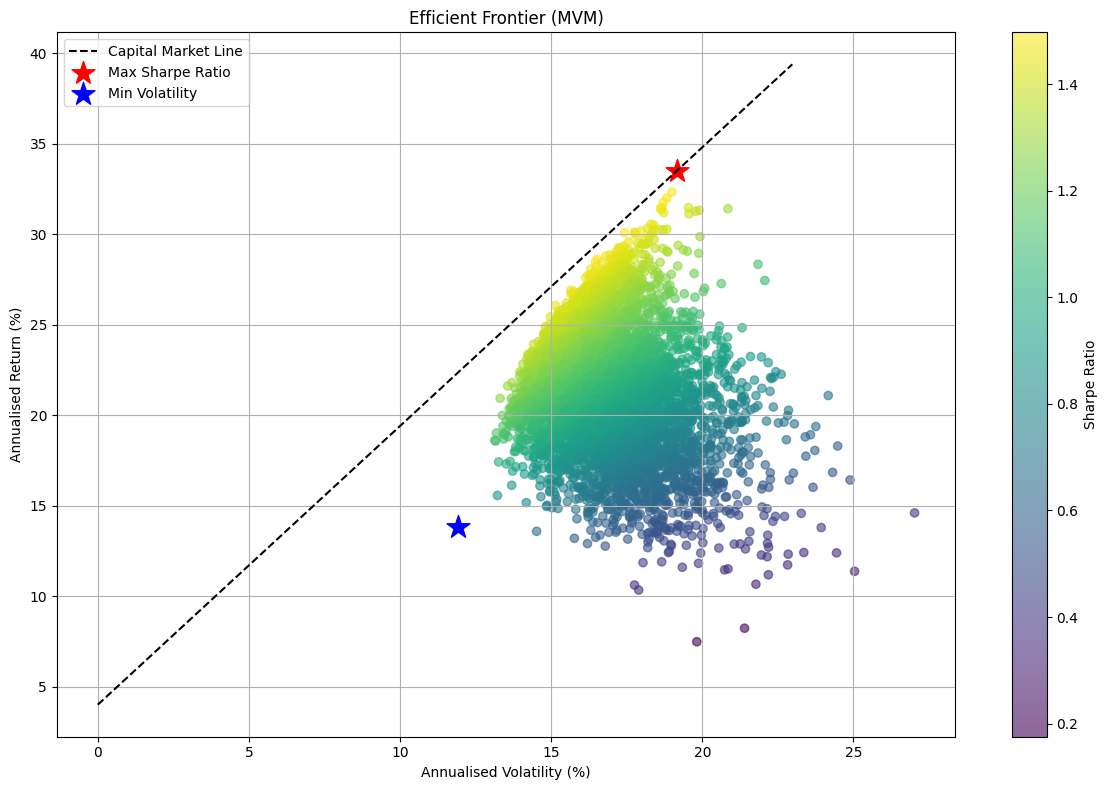

| Asset   |   Max Sharpe (%) |   Min Volatility (%) |
|---------|------------------|----------------------|
| AAPL    |             5.02 |                10.10 |
| AMZN    |            20.28 |                 0.13 |
| BAC     |             3.75 |                 3.55 |
| CHK     |             0.00 |                 0.82 |
| GOOGL   |             3.24 |                 5.23 |
| JNJ     |             5.23 |                44.56 |
| MSFT    |            19.59 |                 3.66 |
| NFLX    |            22.29 |                 0.34 |
| V       |            20.59 |                 3.94 |
| WMT     |             0.00 |                27.68 |

Performance Summary:
Max Sharpe Portfolio:     Return = 33.49%, Volatility = 19.15%, Sharpe Ratio = 1.540
Min Volatility Portfolio: Return = 13.82%, Volatility = 11.92%, Sharpe Ratio = 0.824


In [40]:
if __name__ == "__main__":
    try:
        mvo = MarkowitzMVM("sp500_10s.csv")
        mvo.optimize()
        mvo.plot_efficient_frontier()
        mvo.display_optimal_weights_table()
    except Exception as e:
        print(f"Unexpected error in main execution: {e}")